In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
np.set_printoptions(precision=2)
plt.style.use('/Users/cheerupdimbo/Documents/ds-sprint-july/ds-sprint-july/week3_ml_core/deeplearning.mplstyle')

Using a simple synthetic dataset with 2 features so the pattern is easy to follow — swap this for your own `X_train`, `y_train` (e.g. HDB or SECOM data) once you're comfortable with the flow.

In [6]:
np.random.seed(1)
X_train = np.random.rand(100, 2) * 10        # 100 examples, 2 features, values 0-10
y_train = 3*X_train[:,0] + 5*X_train[:,1] + np.random.normal(0, 2, 100)  # true relationship + noise

**`StandardScaler()`** — scikit-learn's built-in tool for z-score normalization. It's the library equivalent of the `zscore_normalize_features` function you wrote by hand earlier — same math ($\frac{x - \mu}{\sigma}$), just implemented as a reusable object instead of a standalone function.

**`.fit_transform(X_train)`** — Does two things in one call: `.fit(X_train)` computes and internally stores $\mu$ and $\sigma$ for each column of `X_train`; `.transform(X_train)` then applies the normalization formula using those stored values, returning the scaled array. This combo is a shortcut for calling `.fit()` then `.transform()` separately.

**Why the scaler object itself matters (not just the output array)** — `scaler` now *remembers* the $\mu$, $\sigma$ it computed from `X_train`. This matters later: when you get new/unseen data (e.g. a house not in your training set), you must scale it using the **same** $\mu$, $\sigma$ from training — not recompute a fresh mean/std from the new data alone. That's why you call `.transform()` (not `.fit_transform()`) on any new data afterward — this mirrors the "Implementation Note" from the z-score markdown you had earlier, now handled automatically by the object holding onto its fitted state.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"mean stored in scaler: {scaler.mean_}")
print(f"scale (std dev) stored in scaler: {scaler.scale_}")

mean stored in scaler: [4.49 5.22]
scale (std dev) stored in scaler: [3.11 2.96]


**`SGDRegressor`** — Linear regression trained using **Stochastic Gradient Descent**, rather than scikit-learn's `LinearRegression` (which uses a direct linear-algebra solve, the normal equation). This is the scikit-learn model that most closely mirrors the `gradient_descent` function you wrote by hand — it iterates, updating `w` and `b` step by step using a learning-rate-controlled gradient update, rather than solving in one shot.

- `max_iter`: the scikit-learn equivalent of your `num_iters` — the cap on how many passes over the data it takes.
- `eta0`: the initial learning rate — equivalent to your `alpha`. ("SGD" stands for Stochastic Gradient Descent; "eta" is a common symbol for learning rate in optimization literature.)
- `.fit(X_train_scaled, y_train)`: trains the model — note it's fit on the **scaled** data, not the raw `X_train`, since (like your own gradient descent) SGD is sensitive to feature scale.

In [8]:
sgd_model = SGDRegressor(max_iter=1000, eta0=0.01)
sgd_model.fit(X_train_scaled, y_train)

print(f"w (coefficients): {sgd_model.coef_}")
print(f"b (intercept): {sgd_model.intercept_}")

w (coefficients): [ 9.13 14.94]
b (intercept): [39.71]


**`.predict(X_train_scaled)`** — Same role as before: applies the learned `w`, `b` to compute $f_{w,b}(x)$ for each row. Predicting on `X_train_scaled` here (not raw `X_train`) since the model was trained on scaled features — feeding it unscaled data would produce meaningless predictions.

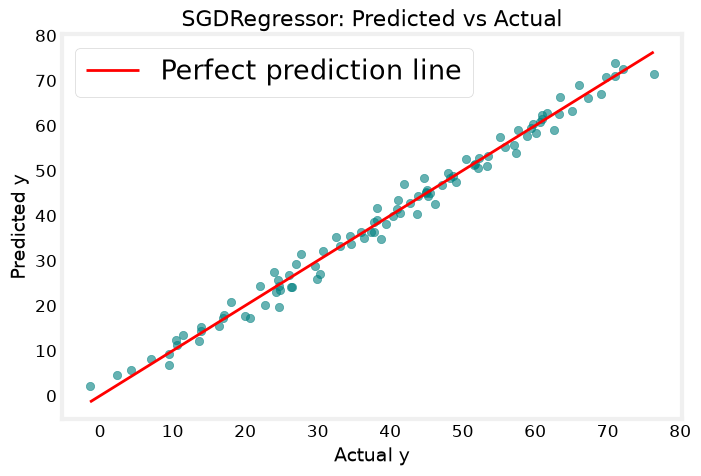

In [9]:
y_pred = sgd_model.predict(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_pred, color='teal', alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('SGDRegressor: Predicted vs Actual')
plt.legend()
plt.show()